### SGD

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class SGDClassifier:
    def __init__(self, learning_rate=0.01, n_epochs=100, batch_size=32, random_state=None):
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def lr_objective(self, X, y, weights, bias):
        # Logistic Regression cross-entropy loss
        linear_model = np.dot(X, weights) + bias
        y_predicted = self.sigmoid(linear_model)
        # Clip probabilities to avoid log(0)
        y_predicted = np.clip(y_predicted, 1e-10, 1 - 1e-10)
        loss = -np.mean(y * np.log(y_predicted) + (1 - y) * np.log(1 - y_predicted))
        return loss

    def make_batches(self, X, y):
        if self.random_state:
            np.random.seed(self.random_state)

        n_samples = X.shape[0]
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        for i in range(0, n_samples, self.batch_size):
            batch_indices = indices[i:i + self.batch_size]
            yield X[batch_indices], y[batch_indices]

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Convert labels to 0 and 1 if not already (assuming binary classification)
        y_ = np.where(y > 0, 1, 0)

        for epoch in range(self.n_epochs):
            epoch_losses = []
            for X_batch, y_batch in self.make_batches(X, y_):
                # Calculate linear model output
                linear_model = np.dot(X_batch, self.weights) + self.bias
                y_predicted = self.sigmoid(linear_model)

                # Calculate gradients
                dw = np.dot(X_batch.T, (y_predicted - y_batch)) / len(y_batch)
                db = np.sum(y_predicted - y_batch) / len(y_batch)

                # Update parameters
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

                # Calculate and store batch loss for this epoch
                epoch_losses.append(self.lr_objective(X_batch, y_batch, self.weights, self.bias))

            # Store average epoch loss
            self.loss_history.append(np.mean(epoch_losses))

            # Optional: Print progress
            # if (epoch + 1) % 10 == 0: # Print every 10 epochs
            #    print(f"Epoch {epoch+1}/{self.n_epochs}, Loss: {self.loss_history[-1]:.4f}")

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

print("SGDClassifier class defined.")

SGDClassifier class defined.


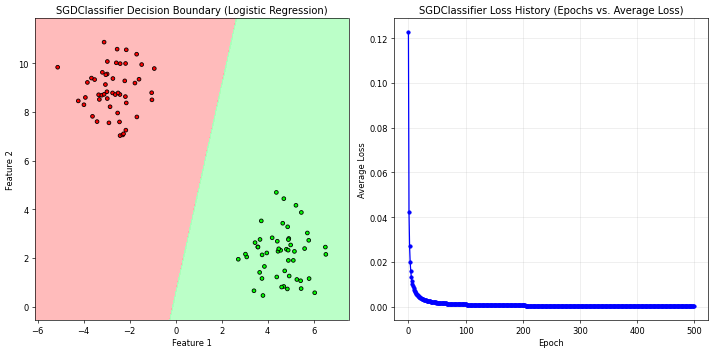

SGDClassifier Accuracy: 1.00


In [13]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Generate some synthetic data for logistic regression
# Using the same data generation as before for consistency
X_sgd, y_sgd = make_blobs(n_samples=100, n_features=2, centers=2, cluster_std=1.0, random_state=42)

# Create an SGDClassifier instance and fit the data
sgd_model = SGDClassifier(learning_rate=0.1, n_epochs=500, batch_size=10, random_state=42)
sgd_model.fit(X_sgd, y_sgd)

# Plot the decision boundary
# We can reuse the plot_decision_boundary function, but need to adapt y for SGDClassifier's predict output (0/1)
def plot_decision_boundary_sgd(X, y, model, ax, title="SGDClassifier Decision Boundary"):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    cmap_light = ListedColormap(['#FFAAAA', '#AAFFBB'])
    cmap_bold = ListedColormap(['#FF0000', '#00FF00'])

    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

    # Plot the training points
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=20)
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), dpi=60)

# Plot decision boundary on the first subplot
plot_decision_boundary_sgd(X_sgd, y_sgd, sgd_model, ax1, title="SGDClassifier Decision Boundary (Logistic Regression)")

# Plot the loss history on the second subplot
ax2.plot(range(len(sgd_model.loss_history)), sgd_model.loss_history, marker='o', linestyle='-', markersize=4, color='blue')
ax2.set_title("SGDClassifier Loss History (Epochs vs. Average Loss)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Average Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Evaluate accuracy
y_pred_sgd = sgd_model.predict(X_sgd)
y_true_sgd = np.where(y_sgd > 0, 1, 0) # Ensure y_true is 0 or 1 for comparison
accuracy_sgd = np.sum(y_pred_sgd == y_true_sgd) / len(y_sgd)
print(f"SGDClassifier Accuracy: {accuracy_sgd:.2f}")

### SGD V2 (slightly simpler implementation)

iteration 99, cost: 0.234193
classification error: 0.091


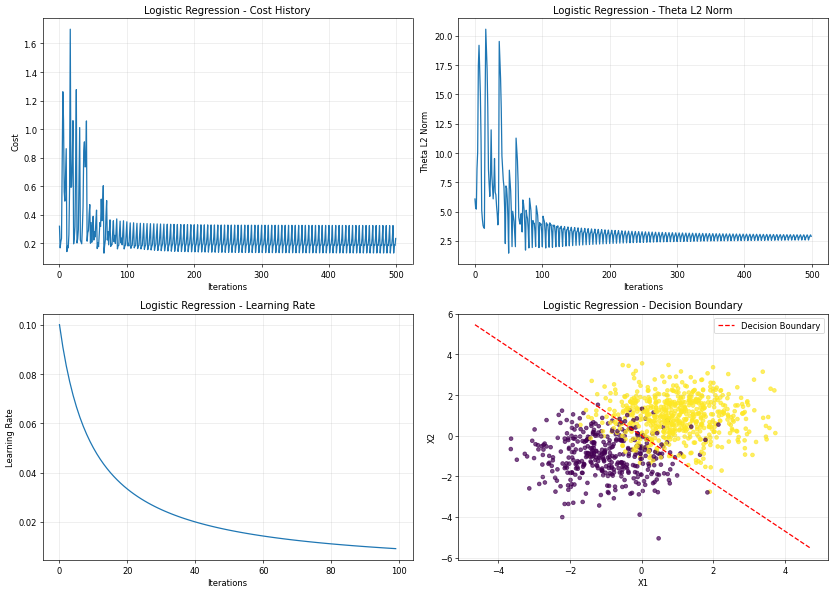

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def generate_data():
    n = 1000
    mu1, mu2, pik = np.array([1,1]), np.array([-1,-1]), np.array([0.4,0.6])

    X = np.zeros((n,2))
    y = np.zeros((n,1))
    for i in range(1,n):
        u = np.random.rand()
        idx = np.where(u < np.cumsum(pik))[0]
        if (len(idx)==1):
            X[i,:] = np.random.randn(1,2) + mu1
            y[i] = 1
        else:
            X[i,:] = np.random.randn(1,2) + mu2
            y[i] = -1
    return X, y

class sgdlr:
    def __init__(self):
        self.num_iter = 100
        self.lmbda = 1e-9
        self.tau0 = 10
        self.kappa = 1
        self.eta = np.zeros(self.num_iter)
        self.batch_size = 200

    def fit(self, X, y):
        #random init
        theta = np.random.randn(X.shape[1],1)

        #learning rate schedule
        for i in range(self.num_iter):
            self.eta[i] = (self.tau0+i)**(-self.kappa)

        #divide data in batches
        batch_data, batch_labels = self.make_batches(X,y,self.batch_size)
        num_batches = batch_data.shape[0]
        num_updates = 0

        J_hist = np.zeros((self.num_iter * num_batches,1))
        t_hist = np.zeros((self.num_iter * num_batches,1))

        for itr in range(self.num_iter):
            for b in range(num_batches):
                Xb = batch_data[b]
                yb = batch_labels[b]
                J_cost, J_grad = self.lr_objective(theta, Xb, yb, self.lmbda)
                theta = theta - self.eta[itr]*(num_batches*J_grad)
                J_hist[num_updates] = J_cost
                t_hist[num_updates] = np.linalg.norm(theta,2)
                num_updates = num_updates + 1
        print("iteration %d, cost: %f" %(itr, J_cost))

        y_pred = 2*(self.sigmoid(X.dot(theta)) > 0.5) - 1
        y_err = np.size(np.where(y_pred - y)[0])/float(y.shape[0])
        print("classification error:", y_err)
        self.generate_plots(X, J_hist, t_hist, theta)
        return theta

    def make_batches(self, X, y, batch_size):
        n = X.shape[0]
        d = X.shape[1]
        num_batches = int(np.ceil(n/batch_size))

        groups = np.tile(range(num_batches),batch_size)
        batch_data=np.zeros((num_batches,batch_size,d))
        batch_labels=np.zeros((num_batches,batch_size,1))
        for i in range(num_batches):
            batch_data[i,:,:] = X[groups==i,:]
            batch_labels[i,:] = y[groups==i]

        return batch_data, batch_labels

    def lr_objective(self, theta, X, y, lmbda):
        n = y.shape[0]
        y01 = (y+1)/2.0
        #compute the objective
        mu = self.sigmoid(X.dot(theta))
        #bound away from 0 and 1
        eps = np.finfo(float).eps
        mu = np.maximum(mu,eps)
        mu = np.minimum(mu,1-eps)
        #compute cost
        cost = -(1/n)*np.sum(y01*np.log(mu)+(1-y01)*np.log(1-mu))+np.sum(lmbda*theta*theta)
        #compute the gradient of the lr objective
        grad = X.T.dot(mu-y01) + 2*lmbda*theta
        #compute the Hessian of the lr objective
        #H = X.T.dot(np.diag(np.diag( mu*(1-mu) ))).dot(X) + 2*lmbda*np.eye(np.size(theta))
        return cost, grad

    def sigmoid(self, a):
        return 1/(1+np.exp(-a))

    def generate_plots(self, X, J_hist, t_hist, theta):
        fig, axes = plt.subplots(2, 2, figsize=(14, 10),)
        axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

        # Plot 1: Loss History
        axes[0].plot(J_hist)
        axes[0].set_title("Logistic Regression - Cost History")
        axes[0].set_xlabel('Iterations')
        axes[0].set_ylabel('Cost')
        axes[0].grid(True, alpha=0.3)

        # Plot 2: Theta L2 Norm History
        axes[1].plot(t_hist)
        axes[1].set_title("Logistic Regression - Theta L2 Norm")
        axes[1].set_xlabel('Iterations')
        axes[1].set_ylabel('Theta L2 Norm')
        axes[1].grid(True, alpha=0.3)

        # Plot 3: Learning Rate History
        axes[2].plot(self.eta)
        axes[2].set_title("Logistic Regression - Learning Rate")
        axes[2].set_xlabel('Iterations')
        axes[2].set_ylabel('Learning Rate')
        axes[2].grid(True, alpha=0.3)

        # Plot 4: Decision Boundary
        x1 = np.linspace(np.min(X[:,0])-1, np.max(X[:,0])+1, 10)
        axes[3].scatter(X[:,0], X[:,1], c=y.flatten(), cmap='viridis', s=20, alpha=0.7)
        # Ensure theta[0] and theta[1] are not zero to avoid division by zero
        if theta[1] != 0:
            axes[3].plot(x1, -(theta[0]/theta[1])*x1, color='red', linestyle='--', label='Decision Boundary')
        else:
            axes[3].axvline(x=-(theta[2]/theta[0]), color='red', linestyle='--', label='Decision Boundary') # Assuming a 3-feature case for vertical line if theta[1] is 0
        axes[3].set_title('Logistic Regression - Decision Boundary')
        axes[3].set_xlabel('X1')
        axes[3].set_ylabel('X2')
        axes[3].grid(True, alpha=0.3)
        axes[3].legend()

        plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
        plt.show()

if __name__ == "__main__":

    X, y = generate_data()
    sgd = sgdlr()
    theta = sgd.fit(X,y)
